<a href="https://colab.research.google.com/github/vrj87/Python-Colab/blob/main/Predictive_Analysis_Walmart_Data_Set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Analytics

# Walmart Customer Purchases

This dataset contains 50,000 customer transactions from Walmart, capturing essential details about consumer shopping behavior. It includes demographic information, product categories, purchase amounts, discounts, and ratings, making it useful for data analysis, customer segmentation, and sales forecasting.

# Importing Dataset:

In [22]:
import pandas as pd
df = pd.read_csv("Walmart_customer_purchases.csv")
df.head()

,Customer_ID,Age,Gender,City,Category,Product_Name,Purchase_Date,Purchase_Amount,Payment_Method,Discount_Applied,Rating,Repeat_Customer
0,84607c1f-910c-44d5-b89f-e1ee06dd34c0,49,Female,New Cynthia,Electronics,Smartphone,2024-08-30,253.26,Cash on Delivery,No,1,Yes
1,f2a81712-a73e-4424-8b39-4c615a0bd4ea,36,Other,Cruzport,Clothing,T-Shirt,2024-12-21,73.19,Debit Card,Yes,1,No
2,da9be287-8b0e-4688-bccd-1a2cdd7567c6,52,Male,Jeffreytown,Beauty,Perfume,2024-12-26,125.62,Credit Card,Yes,1,No
3,50ec6932-3ac7-492f-9e55-4b148212f302,47,Female,Jenniferburgh,Electronics,Smartwatch,2024-11-04,450.32,Credit Card,No,2,Yes
4,8fdc3098-fc75-4b0f-983c-d8d8168c6362,43,Other,Kingshire,Electronics,Smartphone,2024-10-07,369.28,Credit Card,Yes,2,Yes


# Exploratory Data Analysis: (EDA)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Basic Info
print("DataFrame Structure and Data Types:\n")
print(df.info())

# 2. Summary Statistics
print("\n Summary Statistics for Numerical & Categorical Data:\n")
print(df.describe(include='all'))

# 3. Missing Values
print("\n Missing Values in Each Column:\n")
print(df.isnull().sum())

# 4. Value Counts for Categorical Columns
categorical_cols = ['Gender', 'City', 'Category', 'Payment_Method', 'Discount_Applied', 'Repeat_Customer']
for col in categorical_cols:
    print(f"\n Frequency of Categories in '{col}':")
    print(df[col].value_counts())

DataFrame Structure and Data Types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       50000 non-null  object 
 1   Age               50000 non-null  int64  
 2   Gender            50000 non-null  object 
 3   City              50000 non-null  object 
 4   Category          50000 non-null  object 
 5   Product_Name      50000 non-null  object 
 6   Purchase_Date     50000 non-null  object 
 7   Purchase_Amount   50000 non-null  float64
 8   Payment_Method    50000 non-null  object 
 9   Discount_Applied  50000 non-null  object 
 10  Rating            50000 non-null  int64  
 11  Repeat_Customer   50000 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 4.6+ MB
None

 Summary Statistics for Numerical & Categorical Data:

                                 Customer_ID           Age Gender  \
coun

# Visualizing the data : EDA


 Plot: Distribution of Purchase Amount


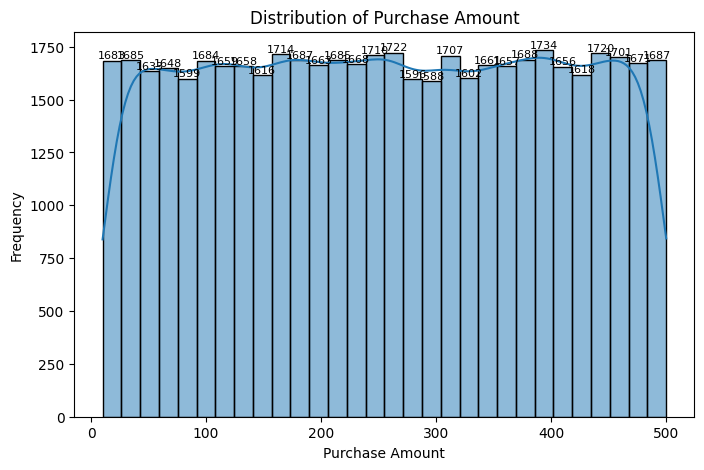


 Plot: Product Category Count


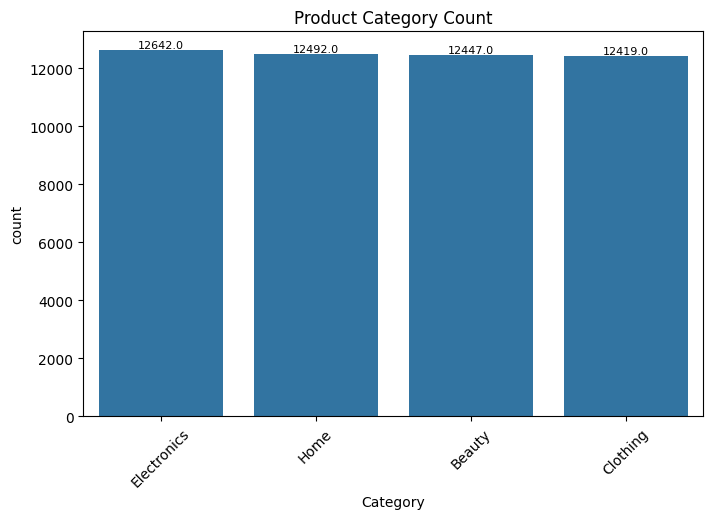


 Plot: Purchase Amount Distribution by Gender


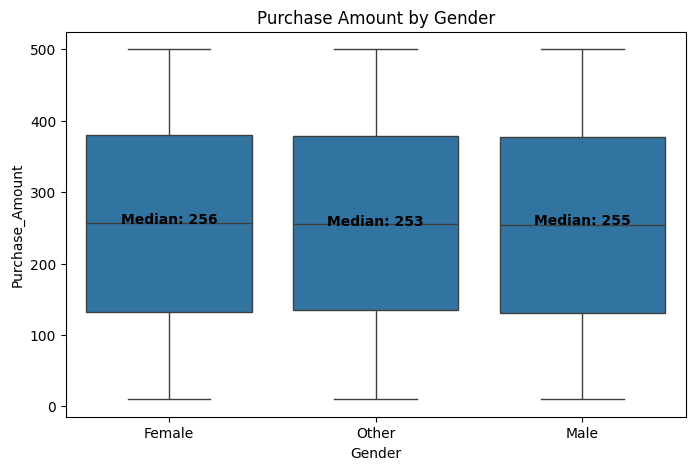


 Plot: Ratings Distribution


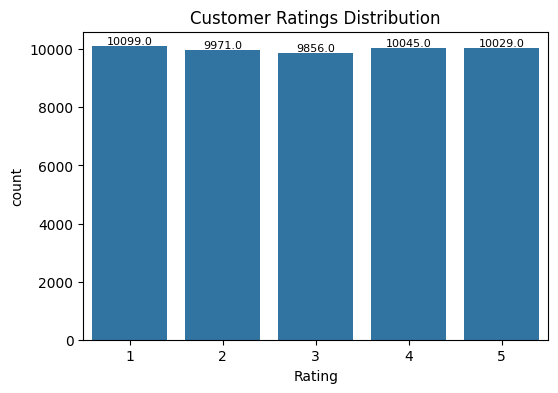

In [24]:
# 5. Distribution of Purchase Amount
print("\n Plot: Distribution of Purchase Amount")
plt.figure(figsize=(8, 5))
plot = sns.histplot(df['Purchase_Amount'], kde=True, bins=30)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
for p in plot.patches:
    height = p.get_height()
    if height > 0:
        plot.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                      ha='center', va='bottom', fontsize=8, color='black')
plt.show()


# 6. Category Count
print("\n Plot: Product Category Count")
plt.figure(figsize=(8, 5))
plot = sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index)
plt.title('Product Category Count')
plt.xticks(rotation=45)
for p in plot.patches:
    height = p.get_height()
    plot.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height),
                  ha='center', va='bottom', fontsize=8, color='black')
plt.show()


# 7. Purchase Amount by Gender
print("\n Plot: Purchase Amount Distribution by Gender")
plt.figure(figsize=(8, 5))
plot = sns.boxplot(data=df, x='Gender', y='Purchase_Amount')
plt.title('Purchase Amount by Gender')
medians = df.groupby("Gender")["Purchase_Amount"].median()
for i, median in enumerate(medians):
    plt.text(i, median, f'Median: {int(median)}', horizontalalignment='center', color='black', weight='semibold')
plt.show()

# 8. Ratings Distribution
print("\n Plot: Ratings Distribution")
plt.figure(figsize=(6, 4))
plot = sns.countplot(data=df, x='Rating')
plt.title('Customer Ratings Distribution')
for p in plot.patches:
    height = p.get_height()
    plot.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height),
                  ha='center', va='bottom', fontsize=8, color='black')
plt.show()

# Data Preprocessing:

In [25]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Load data (make sure 'df' is defined from earlier)
print("\n Starting Data Preprocessing...")

# 1. Convert 'Purchase_Date' to datetime
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
print("\n Converted 'Purchase_Date' to datetime.")

# 2. Drop 'Customer_ID'
df.drop(columns=['Customer_ID'], inplace=True)
print("\n Dropped 'Customer_ID' column (not useful for modeling).")

# 3. Impute missing values
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Impute numeric with median
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])
print("\n Imputed missing numeric values with median.")

# Impute categorical with most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
print("\n Imputed missing categorical values with most frequent category.")

# 4. Remove outliers in Purchase_Amount
Q1 = df['Purchase_Amount'].quantile(0.25)
Q3 = df['Purchase_Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
initial_shape = df.shape[0]
df = df[(df['Purchase_Amount'] >= lower) & (df['Purchase_Amount'] <= upper)]
final_shape = df.shape[0]
print(f"\n Removed outliers from 'Purchase_Amount'. Rows reduced from {initial_shape} to {final_shape}.")

# 5. Label encode binary categorical columns
label_enc_cols = ['Gender', 'Discount_Applied', 'Repeat_Customer']
label_enc = LabelEncoder()
for col in label_enc_cols:
    df[col] = label_enc.fit_transform(df[col])
print("\n Label-encoded binary columns: Gender, Discount_Applied, Repeat_Customer.")

# 6. One-hot encode multi-category columns
multi_cat_cols = ['City', 'Category', 'Product_Name', 'Payment_Method']
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
print(f"\n One-hot encoded multi-category columns: {', '.join(multi_cat_cols)}.")

# 7. Feature engineering: Add Purchase_Month
df['Purchase_Month'] = df['Purchase_Date'].dt.month
df.drop(columns=['Purchase_Date'], inplace=True)
print("\n Created new feature 'Purchase_Month' and dropped 'Purchase_Date'.")

# 8. Scale numeric features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
print("\n Scaled numerical features using StandardScaler.")

# Final summary
print("\n Final preprocessed dataset shape:", df.shape)
print(df.head())


 Starting Data Preprocessing...

 Converted 'Purchase_Date' to datetime.

 Dropped 'Customer_ID' column (not useful for modeling).

 Imputed missing numeric values with median.

 Imputed missing categorical values with most frequent category.

 Removed outliers from 'Purchase_Amount'. Rows reduced from 50000 to 50000.

 Label-encoded binary columns: Gender, Discount_Applied, Repeat_Customer.

 One-hot encoded multi-category columns: City, Category, Product_Name, Payment_Method.

 Created new feature 'Purchase_Month' and dropped 'Purchase_Date'.

 Scaled numerical features using StandardScaler.

 Final preprocessed dataset shape: (50000, 25123)
        Age  Gender  Purchase_Amount  Discount_Applied    Rating  \
0  0.810999       0        -0.016050                 0 -1.409564   
1 -0.237556       2        -1.287973                 1 -1.409564   
2  1.052974       1        -0.917634                 1 -1.409564   
3  0.649683       0         1.375882                 0 -0.704317   
4  0.32



# Logistic Regression and Data Tree Models


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the target variable and features
# Let's assume we want to predict 'Repeat_Customer' based on other features.
# We'll use 'Repeat_Customer' as the target variable (y).
# All other preprocessed columns will be features (X).

# Check if 'Repeat_Customer' is still in the DataFrame after preprocessing
if 'Repeat_Customer' not in df.columns:
    print("Error: 'Repeat_Customer' column not found after preprocessing.")
else:
    X = df.drop('Repeat_Customer', axis=1)
    y = df['Repeat_Customer']

    # Handle potential non-numeric columns if any were missed during preprocessing
    X = X.select_dtypes(include=np.number)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    print("\nSplit data into training and testing sets:")
    print(f"Training features shape: {X_train.shape}")
    print(f"Testing features shape: {X_test.shape}")
    print(f"Training target shape: {y_train.shape}")
    print(f"Testing target shape: {y_test.shape}")

    # --- Logistic Regression Model ---
    print("\n--- Building Logistic Regression Model ---")

    # Initialize and train the Logistic Regression model
    log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
    log_reg_model.fit(X_train, y_train)

    print(" Logistic Regression model trained.")

    # Make predictions on the test set
    y_pred_lr = log_reg_model.predict(X_test)

    # Evaluate the model
    print("\nLogistic Regression Model Evaluation:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_lr))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_lr))



Split data into training and testing sets:
Training features shape: (35000, 6)
Testing features shape: (15000, 6)
Training target shape: (35000,)
Testing target shape: (15000,)

--- Building Logistic Regression Model ---
 Logistic Regression model trained.

Logistic Regression Model Evaluation:
Accuracy: 0.4986

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.24      0.32      7427
           1       0.50      0.75      0.60      7573

    accuracy                           0.50     15000
   macro avg       0.49      0.50      0.46     15000
weighted avg       0.49      0.50      0.46     15000


Confusion Matrix:
[[1771 5656]
 [1865 5708]]


# Decision Tree Model

In [27]:
print("\n\n--- Building Decision Tree Model ---")

# Initialize and train the Decision Tree model
# Use a max_depth to prevent overfitting, or leave None for full growth.
# min_samples_split and min_samples_leaf also helps with regularization
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

print(" Decision Tree model trained.")

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
print("\nDecision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))


# Feature Importance (for Decision Tree)
print("\nDecision Tree Feature Importances:")
feature_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
print(feature_importances.sort_values(ascending=False).head(10)) # Show top 10 important features





--- Building Decision Tree Model ---
 Decision Tree model trained.

Decision Tree Model Evaluation:
Accuracy: 0.5021

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.27      0.35      7427
           1       0.50      0.73      0.60      7573

    accuracy                           0.50     15000
   macro avg       0.50      0.50      0.47     15000
weighted avg       0.50      0.50      0.47     15000


Confusion Matrix:
[[2005 5422]
 [2047 5526]]

Decision Tree Feature Importances:
Purchase_Amount     0.683742
Age                 0.226142
Purchase_Month      0.045092
Rating              0.045024
Gender              0.000000
Discount_Applied    0.000000
dtype: float64


# Analysis and Comparison

In [28]:
# --- Analysis and Comparison ---
print("\n\n--- Model Analysis and Comparison ---")
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Decision Tree Test Accuracy:       {accuracy_score(y_test, y_pred_dt):.4f}")





--- Model Analysis and Comparison ---
Logistic Regression Test Accuracy: 0.4986
Decision Tree Test Accuracy:       0.5021


# Random Forest

In [29]:
##Features Summary:
#Categorical: Gender, City, Category, Product_Name, Payment_Method, Discount_Applied

#Numerical: Age, Purchase_Amount, Rating

#Date: Purchase_Date

#Target (for classification): Repeat_Customer (Yes/No)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv("Walmart_customer_purchases.csv")

df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
df['Purchase_Month'] = df['Purchase_Date'].dt.month
df.drop(columns=['Customer_ID', 'Purchase_Date', 'Product_Name'], inplace=True)

# Encode categorical variables
categorical_cols = ['Gender', 'City', 'Category', 'Payment_Method', 'Discount_Applied']
df = pd.get_dummies(df, columns=categorical_cols)

# Encode target variable
label_encoder = LabelEncoder()
df['Repeat_Customer'] = label_encoder.fit_transform(df['Repeat_Customer'])

# Split dataset
X = df.drop('Repeat_Customer', axis=1)
y = df['Repeat_Customer']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.5028
              precision    recall  f1-score   support

           0       0.50      0.46      0.48      4989
           1       0.50      0.55      0.53      5011

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



# Gradient Boosting

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming `model` is your trained GradientBoostingClassifier and `X` is your feature DataFrame
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


ValueError: Length of values (25113) does not match length of index (6)

# KNN

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
df = pd.read_csv("C:/Users/RSai/Downloads/PA assignment 2/Walmart_customer_purchases.csv")


# Convert date column to datetime and extract month
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], errors='coerce')  # in case of invalid dates
df['Purchase_Month'] = df['Purchase_Date'].dt.month

# Drop columns not needed for modeling
df.drop(columns=['Customer_ID', 'Purchase_Date', 'Product_Name'], inplace=True)

# Encode target variable
label_encoder = LabelEncoder()
df['Repeat_Customer'] = label_encoder.fit_transform(df['Repeat_Customer'])

# One-hot encode categorical variables
categorical_cols = ['Gender', 'City', 'Category', 'Payment_Method', 'Discount_Applied']
df = pd.get_dummies(df, columns=categorical_cols)

# Final features and target
X = df.drop('Repeat_Customer', axis=1)
y = df['Repeat_Customer']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sanity check: Ensure no object (string) columns remain
assert not X_train.select_dtypes(include='object').any().any(), "Still string values in X_train"

# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

# Evaluate
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Report:\n", classification_report(y_test, y_pred_knn))



In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# First reduce X_train and X_test to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Fit KNN on reduced data
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_train_pca, y_train)

# Create meshgrid for background decision boundaries
h = 0.1  # step size in the mesh
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict over meshgrid
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolor='k', cmap='coolwarm')
plt.title("KNN Decision Boundary (PCA-reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
legend = plt.legend(*scatter.legend_elements(), title="Repeat")
plt.grid(True)
plt.show()


# Naive Bayes

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("C:/Users/RSai/Downloads/PA assignment 2/Walmart_customer_purchases.csv")

# Convert date
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
df['Purchase_Month'] = df['Purchase_Date'].dt.month

# Drop high-cardinality and non-useful columns
df.drop(columns=['Customer_ID', 'Purchase_Date', 'Product_Name'], inplace=True)

# Identify categorical columns
categorical_cols = ['Gender', 'City', 'Category', 'Payment_Method', 'Discount_Applied']

# Apply Label Encoding (better for memory than one-hot)
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Encode target variable
df['Repeat_Customer'] = le.fit_transform(df['Repeat_Customer'])

# Features and target
X = df.drop('Repeat_Customer', axis=1)
y = df['Repeat_Customer']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
